# Baseline: PCA + K-Means on Root-Node Features

This notebook addresses the **curse of dimensionality** for K-Means clustering by first
reducing the 27-dimensional root-node feature vectors with **PCA**, then clustering in
the lower-dimensional space.

It is directly comparable to `train_baseline_on_raw_graph.ipynb` (same dataset, same
train/test split, same evaluation metrics), with PCA as the only structural difference.

## Workflow
1. Load the cached PyG graph dataset from `data/gnn_graph_dataset.pkl`
2. Extract the **root-node raw feature vector** (`data.x[0]`, dim=27) for each package
3. Apply the same train/test split as the GNN notebook (80/20, seed=42)
4. Standardise features, then fit **PCA** — choose `n_components` by explained-variance threshold (95%)
5. Fit K-Means on the PCA-reduced test set via the Elbow Method
6. Evaluate: risk score per cluster → top-K% clusters → Recall / Precision / F1

## Setup

In [1]:
import sys
import os
import pickle
import random

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib

# Paths
GRAPH_CACHE   = '../data/gnn_graph_dataset.pkl'
MODEL_OUTPUT  = '../models/lib/pca_kmeans.pkl'
PCA_OUTPUT    = '../models/lib/pca_transformer.pkl'
SCALER_OUTPUT = '../models/lib/pca_scaler.pkl'

# Hyper-parameters (match train_gnn_model.ipynb)
TRAIN_RATIO   = 0.8
TOP_K_PCT     = 0.33
VAR_THRESHOLD = 0.95   # PCA: retain this fraction of total variance

os.makedirs('../models/lib', exist_ok=True)
print('Setup complete.')

Setup complete.


## Step 1: Load graph dataset

In [2]:
with open(GRAPH_CACHE, 'rb') as f:
    graph_dataset = pickle.load(f)

before = len(graph_dataset)
graph_dataset = [d for d in graph_dataset if d['data'].x.size(0) > 0]
n_empty = before - len(graph_dataset)

n_vuln = sum(1 for d in graph_dataset if d['label'] == 1)
print(f'Loaded {len(graph_dataset)} graphs  ({n_vuln} vulnerable)'
      + (f'  [{n_empty} empty graphs dropped]' if n_empty else ''))

/Users/xipingye/software-supply-chain-risk-detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 9668 graphs  (4823 vulnerable)


## Step 2: Extract raw root-node features

`build_pyg_data` guarantees the seed package is always placed at node index 0.
So `data.x[0]` gives its 27-dimensional raw feature vector directly.

In [3]:
features = []
labels   = []
pkg_ids  = []

for item in tqdm(graph_dataset, desc='Extracting root features'):
    features.append(item['data'].x[0].numpy())
    labels.append(item['label'])
    pkg_ids.append(item['pkg_id'])

X_raw  = np.array(features)   # (N, 27)
labels = np.array(labels)

print(f'Feature matrix : {X_raw.shape}')
print(f'Vulnerable     : {labels.sum()} / {len(labels)}')

Extracting root features: 100%|██████████| 9668/9668 [00:00<00:00, 432220.88it/s]

Feature matrix : (9668, 27)
Vulnerable     : 4823 / 9668


## Step 3: Train / test split

Uses the same seed and ratio as `train_gnn_model.ipynb` so the test sets are identical.

In [4]:
indices = list(range(len(graph_dataset)))
random.seed(42)
random.shuffle(indices)

split_idx     = int(len(indices) * TRAIN_RATIO)
train_indices = indices[:split_idx]
test_indices  = indices[split_idx:]

X_train     = X_raw[train_indices]
X_test      = X_raw[test_indices]
test_labels = labels[test_indices]
test_pkgids = [pkg_ids[i] for i in test_indices]

print(f'Train : {len(X_train)}')
print(f'Test  : {len(X_test)}')
print(f'Vulnerable in test : {test_labels.sum()} / {len(test_labels)}')

Train : 7734
Test  : 1934
Vulnerable in test : 989 / 1934


## Step 4: Standardise then PCA

The scaler and PCA transformer are **fit on the training set** and applied to the test
set to avoid leakage.  We sweep all possible components first to pick `n_components`
by the cumulative explained-variance threshold.

Input dimensionality : 27
PCA components chosen: 20  (explains 95.3% of variance)


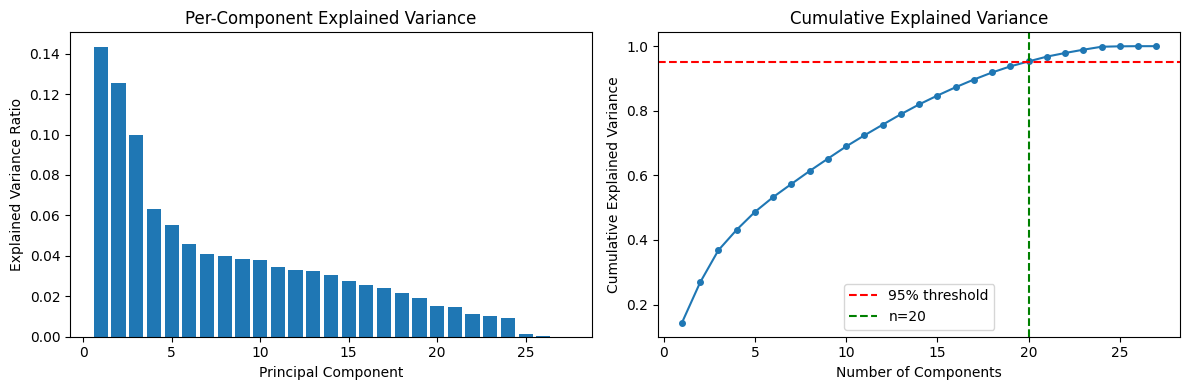

Reduced train shape: (7734, 20)
Reduced test  shape: (1934, 20)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Full PCA on training set to inspect explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cum_var      = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cum_var, VAR_THRESHOLD) + 1)

print(f'Input dimensionality : {X_train_scaled.shape[1]}')
print(f'PCA components chosen: {n_components}  '
      f'(explains {cum_var[n_components-1]*100:.1f}% of variance)')

# Visualise explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Per-Component Explained Variance')

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=4)
axes[1].axhline(VAR_THRESHOLD, color='red', linestyle='--',
                label=f'{VAR_THRESHOLD*100:.0f}% threshold')
axes[1].axvline(n_components, color='green', linestyle='--',
                label=f'n={n_components}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/lib/pca_explained_variance.png', dpi=120)
plt.show()

# Refit PCA with the chosen number of components
pca         = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Reduced train shape: {X_train_pca.shape}')
print(f'Reduced test  shape: {X_test_pca.shape}')

## Step 5: K-Means — Elbow Method on PCA-reduced test features

Elbow sweep: 100%|██████████| 19/19 [00:00<00:00, 25.78it/s]


 K      Inertia        Delta       Delta2  Gain_pct
 2 81376.078125          NaN          NaN       NaN
 3 48872.394531 32503.683594          NaN     39.94
 4 44125.039062  4747.355469 27756.328125      9.71
 5 40028.968750  4096.070312   651.285156      9.28
 6 37131.179688  2897.789062  1198.281250      7.24
 7 34763.210938  2367.968750   529.820312      6.38
 8 32605.687500  2157.523438   210.445312      6.21
 9 30718.757812  1886.929688   270.593750      5.79
10 29560.398438  1158.359375   728.570312      3.77
11 28019.056641  1541.341797   382.982422      5.21
12 26995.632812  1023.423828   517.917969      3.65
13 25376.107422  1619.525391   596.101562      6.00
14 24980.859375   395.248047  1224.277344      1.56
15 23906.951172  1073.908203   678.660156      4.30
16 22274.210938  1632.740234   558.832031      6.83
17 21604.738281   669.472656   963.267578      3.01
18 20370.792969  1233.945312   564.472656      5.71
19 19559.417969   811.375000   422.570312      3.98
20 18818.300

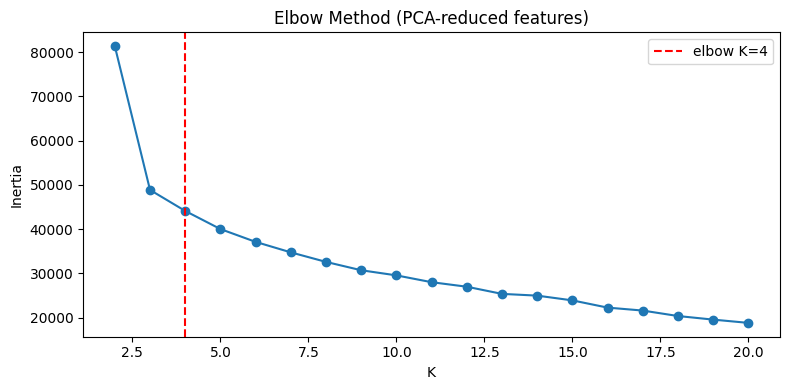

In [6]:
K_RANGE  = range(2, 21)
inertias = {}

for k in tqdm(K_RANGE, desc='Elbow sweep'):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_test_pca)
    inertias[k] = km.inertia_

elbow_df = pd.DataFrame({
    'K'      : list(inertias.keys()),
    'Inertia': list(inertias.values()),
})
elbow_df['Delta']    = elbow_df['Inertia'].diff().abs()
elbow_df['Delta2']   = elbow_df['Delta'].diff().abs()
elbow_df['Gain_pct'] = (elbow_df['Delta'] / elbow_df['Inertia'].shift(1) * 100).round(2)

print(elbow_df.to_string(index=False))

best_k = int(elbow_df.loc[elbow_df['Delta2'].idxmax(), 'K'])
print(f'\nAuto-detected elbow K = {best_k}')

plt.figure(figsize=(8, 4))
plt.plot(elbow_df['K'], elbow_df['Inertia'], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'elbow K={best_k}')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method (PCA-reduced features)')
plt.legend()
plt.tight_layout()
plt.savefig('../models/lib/pca_kmeans_elbow.png', dpi=120)
plt.show()

In [7]:
# Override best_k here if you disagree with the auto-detection
# best_k = 10

final_km       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_km.fit_predict(X_test_pca)

results_df = pd.DataFrame({
    'pkg_id' : test_pkgids,
    'label'  : test_labels,
    'cluster': cluster_labels,
})

print(f'Trained KMeans with K={best_k}')
print(results_df.groupby('cluster')['label'].agg(['sum', 'count']).rename(
    columns={'sum': 'n_vulnerable', 'count': 'cluster_size'}
))

Trained KMeans with K=4
         n_vulnerable  cluster_size
cluster                            
0                 832          1738
1                   0             1
2                   3             5
3                 154           190


In [ ]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_test_pca, cluster_labels)
print(f'Silhouette score (K={best_k}, PCA-reduced): {sil:.4f}')
print('  > 0.5   → strong structure')
print('  0.2–0.5 → moderate structure')
print('  < 0.2   → weak / overlapping clusters')

## Step 6: Evaluate

**Risk score** per cluster = `n_vulnerable / cluster_size`  
**Top-K clusters** = top 33% of clusters ranked by risk score

Metrics:
- **Recall** — fraction of all known-vulnerable packages that fall in the top-K clusters
- **Precision** — fraction of packages inside the top-K clusters that are actually vulnerable
- **F1** — harmonic mean of Recall and Precision

In [ ]:
cluster_stats = (
    results_df.groupby('cluster')['label']
    .agg(n_vulnerable='sum', cluster_size='count')
    .assign(risk_score=lambda df: df['n_vulnerable'] / df['cluster_size'])
    .sort_values('risk_score', ascending=False)
    .reset_index()
)

print('=== All clusters ranked by risk score ===')
print(cluster_stats.to_string(index=False))

# Top-K% of PACKAGES: add clusters in decreasing risk order until ~K% of packages are flagged
n_top_pkgs = max(1, round(len(results_df) * TOP_K_PCT))
top_clusters = set()
n_flagged = 0
for _, row in cluster_stats.iterrows():
    top_clusters.add(int(row['cluster']))
    n_flagged += int(row['cluster_size'])
    if n_flagged >= n_top_pkgs:
        break
print(f'\nTop clusters covering ~{TOP_K_PCT*100:.0f}% of packages ({n_flagged} / {len(results_df)}): {top_clusters}')

total_vulnerable = (results_df['label'] == 1).sum()
in_top_mask      = results_df['cluster'].isin(top_clusters)
true_positives   = ((results_df['label'] == 1) & in_top_mask).sum()
top_cluster_size = in_top_mask.sum()

recall    = true_positives / total_vulnerable if total_vulnerable else 0.0
precision = true_positives / top_cluster_size if top_cluster_size  else 0.0
f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

print(f'\n--- Evaluation (top ~{TOP_K_PCT*100:.0f}% packages as "risky") ---')
print(f'PCA components used : {n_components}  (covers {cum_var[n_components-1]*100:.1f}% variance)')
print(f'Total packages      : {len(results_df)}')
print(f'Total vulnerable    : {total_vulnerable}')
print(f'Flagged packages    : {top_cluster_size}')
print(f'True positives      : {true_positives}')
print(f'Recall              : {recall:.4f}  ({recall*100:.1f}%)')
print(f'Precision           : {precision:.4f}  ({precision*100:.1f}%)')
print(f'F1                  : {f1:.4f}')

## Step 7: Save model

In [9]:
joblib.dump(final_km, MODEL_OUTPUT)
joblib.dump(pca,      PCA_OUTPUT)
joblib.dump(scaler,   SCALER_OUTPUT)

cluster_stats.to_csv('../models/lib/pca_cluster_risk_scores.csv', index=False)

print(f'KMeans saved      -> {MODEL_OUTPUT}')
print(f'PCA saved         -> {PCA_OUTPUT}')
print(f'Scaler saved      -> {SCALER_OUTPUT}')
print(f'Risk scores saved -> ../models/lib/pca_cluster_risk_scores.csv')

KMeans saved      -> ../models/lib/pca_kmeans.pkl
PCA saved         -> ../models/lib/pca_transformer.pkl
Scaler saved      -> ../models/lib/pca_scaler.pkl
Risk scores saved -> ../models/lib/pca_cluster_risk_scores.csv
